In [2]:
import os
import json
from shapely.geometry import Polygon
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from dotenv import load_dotenv

load_dotenv()
PROJECT_ROOT = os.environ.get("PROJECT_ROOT")
PYTHON_IO_ENCODING = os.environ.get("PYTHON_IO_ENCODING")

In [3]:
output_folder = os.path.join(PROJECT_ROOT, "data", "processed", "segmented_images")
files_folder = os.listdir(output_folder)

Calculate the area per bound

In [4]:
area_txt_lines = []
for img_segm in files_folder:
    json_path = os.path.join(output_folder, img_segm)
    with open(json_path, "r", encoding="utf-8") as f:
        kraken_output = json.load(f)
    txt_lines = kraken_output.get("lines", [])
    area_txt_lines.append([Polygon(bounds.get("boundary", [])).area for bounds in txt_lines])

Distribution of number of text lines per image

In [5]:
num_txt_lines = [len(lines) for lines in area_txt_lines]
stats = pd.Series(num_txt_lines).describe(percentiles=[0.1, 0.25, 0.75, 0.90])
stats

count     71.000000
mean     197.338028
std       18.303742
min      101.000000
10%      193.000000
25%      197.000000
50%      201.000000
75%      204.000000
90%      210.000000
max      219.000000
dtype: float64

In [6]:
ind_min_txt_lines = num_txt_lines.index(stats["min"])
print(f"Index of minimum text line count: {ind_min_txt_lines}")
print(f"Corresponding file: {files_folder[ind_min_txt_lines]}")
ind_max_txt_lines = num_txt_lines.index(stats["max"])
print(f"Index of maximum text line count: {ind_max_txt_lines}")
print(f"Corresponding file: {files_folder[ind_max_txt_lines]}")

Index of minimum text line count: 70
Corresponding file: 75_f_070v_garde.json
Index of maximum text line count: 69
Corresponding file: 74_f_069v_070.json


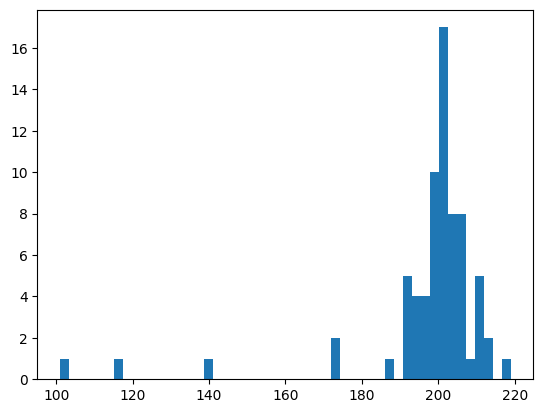

In [ ]:
plt.hist(num_txt_lines,bins=50)
plt.show()

Bound's area distribution overall images

In [7]:
full_area_txt_lines = list(itertools.chain.from_iterable(area_txt_lines))
print(f"Total number of text lines: {len(full_area_txt_lines)}")

Total number of text lines: 14011


In [71]:
stats = pd.Series(full_area_txt_lines).describe(percentiles=[0.01,0.02,0.021,0.022,0.023,0.024,0.025,0.026,0.027,0.028,0.029,0.03,0.031,0.032,0.033,0.04,0.05,0.1, 0.25, 0.75, 0.99,0.995,0.999])
stats

count    14011.000000
mean     12230.803440
std       2562.398822
min        100.500000
1%         750.450000
2%        1526.300000
2.1%      1668.710000
2.2%      1731.710000
2.3%      1879.495000
2.4%      2058.780000
2.5%      2231.375000
2.6%      2466.980000
2.7%      2722.370000
2.8%      3081.280000
2.9%      3502.385000
3%        4058.750000
3.1%      4461.095000
3.2%      4809.120000
3.3%      5480.420000
4%        8416.000000
5%        9557.500000
10%      10788.000000
25%      11684.500000
50%      12474.500000
75%      13253.000000
99%      17092.500000
99.5%    18775.900000
99.9%    29904.155000
max      36947.000000
dtype: float64

In [72]:
large_bounds = [
    (i, j,area_txt_lines[i][j])
    for i, sublist in enumerate(area_txt_lines)
    for j, value in enumerate(sublist)
    if value >= stats["99.5%"]
]

print(len(large_bounds))

71


In [ ]:
small_bounds_2 = [
    (i, j,area_txt_lines[i][j])
    for i, sublist in enumerate(area_txt_lines)
    for j, value in enumerate(sublist)
    if value <= stats["2%"]
]

print(len(small_bounds_2))
sorted_desc_small_bounds = sorted(small_bounds_2, key=lambda x: x[-1], reverse=True)
sorted_desc_small_bounds[:20]

281


[(35, 205, 1526.0),
 (45, 172, 1518.0),
 (39, 85, 1513.5),
 (21, 134, 1513.0),
 (44, 201, 1507.0),
 (36, 83, 1497.0),
 (55, 200, 1489.0),
 (0, 20, 1486.0),
 (45, 72, 1484.0),
 (66, 204, 1484.0),
 (0, 109, 1482.5),
 (21, 85, 1479.5),
 (61, 1, 1474.0),
 (61, 202, 1465.5),
 (1, 3, 1443.5),
 (59, 198, 1433.5),
 (0, 0, 1426.5),
 (67, 199, 1413.0),
 (48, 202, 1406.5),
 (64, 1, 1396.5)]

In [78]:
small_bounds_25 = [
    (i, j,area_txt_lines[i][j])
    for i, sublist in enumerate(area_txt_lines)
    for j, value in enumerate(sublist)
    if value <= stats["2.5%"]
]

print(len(small_bounds_25))
sorted_desc_small_bounds = sorted(small_bounds_25, key=lambda x: x[-1], reverse=True)
sorted_desc_small_bounds[:20]

351


[(38, 15, 2225.0),
 (10, 66, 2216.5),
 (12, 141, 2199.0),
 (17, 4, 2197.0),
 (26, 75, 2181.0),
 (64, 0, 2180.0),
 (45, 64, 2147.0),
 (12, 102, 2128.0),
 (40, 62, 2126.0),
 (4, 93, 2125.5),
 (23, 196, 2099.5),
 (5, 95, 2092.5),
 (65, 200, 2085.0),
 (40, 61, 2066.0),
 (30, 18, 2056.5),
 (5, 0, 2034.5),
 (41, 153, 2012.5),
 (39, 199, 2006.5),
 (11, 107, 1997.5),
 (11, 108, 1981.5)]

In [70]:
print(f"Corresponding file: {files_folder[43]}")

Corresponding file: 48_f_043v_044.json


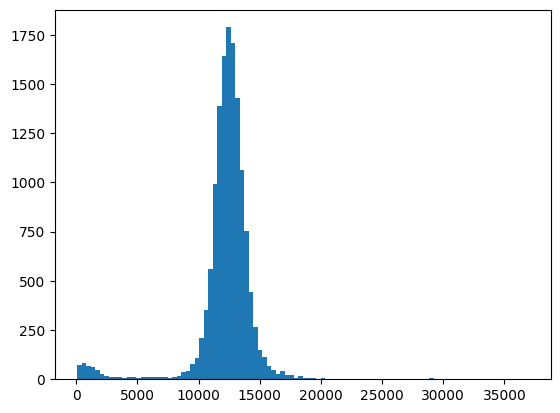

In [77]:
plt.hist(full_area_txt_lines,bins=100)
plt.show()